In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\utilisateur\Downloads\histo_gazpar_merged.csv")


🔹 Identifiants
- pce : Identifiant du compteur gaz.
- pce_releve : Identifiant du relevé associé au compteur.
- pitd : Identifiant du point de télérelève.
- code_station_meteo_pitd : Code de la station météo liée au compteur.
- code_station_meteo_pitd_char : Même chose, mais en format texte.

🔹 Infos client

- segmnt : Segment client (résidentiel / pro / industriel…).
- profil : Profil de consommation (type d’abonnement / usage).
- car : Consommation annuelle de référence (ou catégorie).
- business_u_finale : Catégorie commerciale du client.
- business_u_finale_new : Version nettoyée / corrigée de la précédente.

🔹 Consommation

- valeur_energie_conso : Consommation réelle (kWh).
- conso_theorique : Consommation attendue (modèle ou référence).
- delta_conso : Différence entre réel et attendu.

🔹 Dates et périodes

- date_parsed / date : Date de la mesure.
- year / month / day : Année / mois / jour.
- mois / jour : Même chose en français.
- gasday : Jour “gazier” (qui peut commencer à 6h).
- date_insert : Date d’insertion en base.
- date_debut_periode_parsed : Début de la période mesurée.
- date_fin_periode_parsed : Fin de la période mesurée.
- horodate_debut_conso_local : Heure locale de début consommation.
- horodate_fin_conso_local : Heure locale de fin consommation.

🔹 Météo

- temperature : Température mesurée.
- hdd : Degrés-jours de chauffage (plus il fait froid, plus c’est élevé).
- temperature_de_reference : Température utilisée comme norme.
- hdd_ref : Degrés-jours calculés avec la température de référence.

🔹 Technique / traitement

- freq_rel / freq_rel_1 : Fréquence de relevé (ex : journalier, mensuel).
- event : Type d’événement (relevé réel, estimation, anomalie…).
- row_number : Numéro de ligne (utile pour classement).
- ntile100 : Quantile entre 1 et 100 (classement statistique).

In [39]:
import pandas as pd

# 1. Correction du DataFrame (pour éviter le Warning)
df_final = df_final.copy()

# 2. Conversion propre des dates en format "sans fuseau horaire" (Naive)
# On retire le fuseau UTC pour ne garder que la date brute (YYYY-MM-DD)
df_final['date_parsed'] = pd.to_datetime(df_final['date_parsed']).dt.tz_localize(None)

# 3. Regénération de la liste des jours fériés (Code identique au précédent)
def get_french_holidays(years=[2021, 2022, 2023, 2024, 2025]):
    holidays = []
    for year in years:
        # Fêtes fixes
        holidays.extend([
            f"{year}-01-01", f"{year}-05-01", f"{year}-05-08",
            f"{year}-07-14", f"{year}-08-15", f"{year}-11-01",
            f"{year}-11-11", f"{year}-12-25"
        ])
        # Fêtes mobiles (Lundis de Pâques, Ascension, Pentecôte)
        mobiles = {
            2021: ["2021-04-05", "2021-05-13", "2021-05-24"],
            2022: ["2022-04-18", "2022-05-26", "2022-06-06"],
            2023: ["2023-04-10", "2023-05-18", "2023-05-29"],
            2024: ["2024-04-01", "2024-05-09", "2024-05-20"],
            2025: ["2025-04-21", "2025-05-29", "2025-06-09"]
        }
        if year in mobiles:
            holidays.extend(mobiles[year])
            
    return pd.to_datetime(holidays)

jours_feries = get_french_holidays()

# 4. Création de la colonne Is_Public_Holiday (Comparaison Naive vs Naive)
# .normalize() s'assure qu'on compare bien des dates à minuit pile (00:00:00)
df_final['Is_Public_Holiday'] = df_final['date_parsed'].dt.normalize().isin(jours_feries).astype(int)

# 5. Vérification
print(f"Nombre de jours fériés identifiés : {df_final['Is_Public_Holiday'].sum()}")
print("Exemple de lignes identifiées comme fériées :")
print(df_final[df_final['Is_Public_Holiday'] == 1][['date_parsed', 'Is_Public_Holiday']].head(3))

Nombre de jours fériés identifiés : 40239
Exemple de lignes identifiées comme fériées :
    date_parsed  Is_Public_Holiday
13   2024-07-14                  1
44   2024-08-15                  1
117  2024-11-01                  1


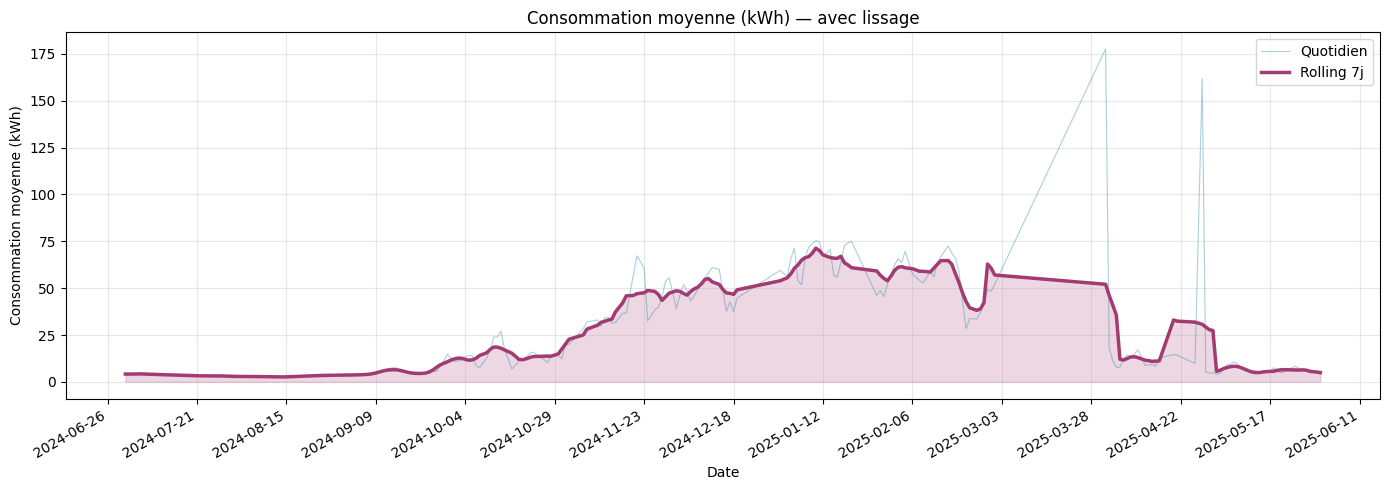

Quotidien — Min: 2.51 kWh | Max: 177.64 kWh | Moy: 23.38 kWh
Rolling 7j — Min: 2.65 kWh | Max: 71.36 kWh | Moy: 23.39 kWh


In [15]:
# Évolution simple de la consommation dans le temps (avec rolling)
import pandas as pd
import matplotlib.pyplot as plt

# Préparer les données
df_plot = df.dropna(subset=['date_parsed', 'valeur_energie_conso']).copy()
df_plot['date_parsed'] = pd.to_datetime(df_plot['date_parsed'], errors='coerce')
df_plot = df_plot.dropna(subset=['date_parsed'])

if df_plot.empty:
    print('Aucune donnée valide avec date et consommation.')
else:
    # Consommation moyenne par jour (pour lisibilité)
    conso_daily = (
        df_plot
        .groupby(df_plot['date_parsed'].dt.date)['valeur_energie_conso']
        .mean()
    )

    # Lissage rolling (fenêtre 7 jours par défaut)
    window = 7
    conso_rolling = conso_daily.rolling(window=window, min_periods=1, center=True).mean()

    # Plot avec rolling
    plt.figure(figsize=(14, 5))
    plt.plot(conso_daily.index, conso_daily.values, linewidth=0.8, alpha=0.4, color='#2E86AB', label='Quotidien')
    plt.plot(conso_rolling.index, conso_rolling.values, linewidth=2.5, color='#A23B72', label=f'Rolling {window}j')
    plt.fill_between(conso_rolling.index, conso_rolling.values, alpha=0.2, color='#A23B72')
    
    plt.title('Consommation moyenne (kWh) — avec lissage')
    plt.xlabel('Date')
    plt.ylabel('Consommation moyenne (kWh)')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    
    # Limiter ticks x pour lisibilité
    if len(conso_daily) > 30:
        plt.gca().xaxis.set_major_locator(plt.MaxNLocator(15))
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    # Afficher statistiques rapides
    print(f"Quotidien — Min: {conso_daily.min():.2f} kWh | Max: {conso_daily.max():.2f} kWh | Moy: {conso_daily.mean():.2f} kWh")
    print(f"Rolling {window}j — Min: {conso_rolling.min():.2f} kWh | Max: {conso_rolling.max():.2f} kWh | Moy: {conso_rolling.mean():.2f} kWh")


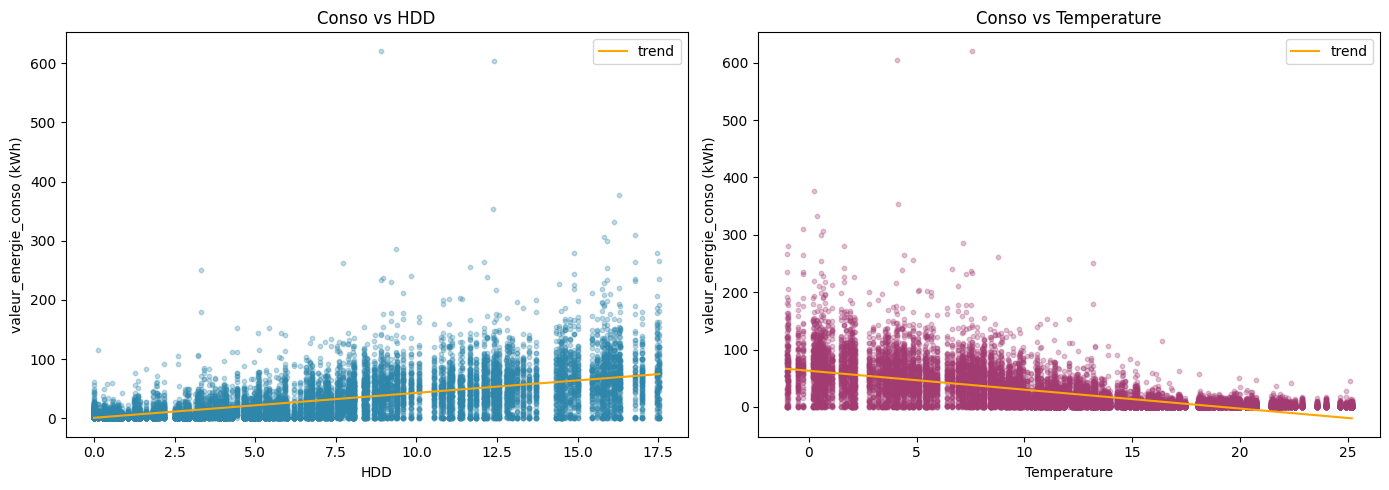

In [16]:
# Scatter simple : consommation vs HDD et consommation vs température
import matplotlib.pyplot as plt
import numpy as np

# Préparer les données (filtre NA)
df_scatter = df.dropna(subset=['valeur_energie_conso']).copy()

# Scatter conso vs hdd
if 'hdd' in df_scatter.columns:
    df_hdd = df_scatter.dropna(subset=['hdd'])
    sample_hdd = df_hdd.sample(min(20000, len(df_hdd)), random_state=1) if len(df_hdd) > 20000 else df_hdd
else:
    sample_hdd = None

# Scatter conso vs temperature
if 'temperature' in df_scatter.columns:
    df_temp = df_scatter.dropna(subset=['temperature'])
    sample_temp = df_temp.sample(min(20000, len(df_temp)), random_state=1) if len(df_temp) > 20000 else df_temp
else:
    sample_temp = None

plt.figure(figsize=(14,5))

# Plot 1 : conso vs hdd
plt.subplot(1,2,1)
if sample_hdd is None or sample_hdd.empty:
    plt.text(0.5,0.5,'Colonne "hdd" absente ou sans données', ha='center')
    plt.axis('off')
else:
    plt.scatter(sample_hdd['hdd'], sample_hdd['valeur_energie_conso'], alpha=0.3, s=10, color='#2E86AB')
    plt.xlabel('HDD')
    plt.ylabel('valeur_energie_conso (kWh)')
    plt.title('Conso vs HDD')
    # optionnel: petite régression linéaire pour repère
    try:
        coef = np.polyfit(sample_hdd['hdd'], sample_hdd['valeur_energie_conso'], 1)
        xs = np.linspace(sample_hdd['hdd'].min(), sample_hdd['hdd'].max(), 100)
        plt.plot(xs, coef[0]*xs + coef[1], color='orange', linewidth=1.5, label='trend')
        plt.legend()
    except Exception:
        pass

# Plot 2 : conso vs temperature
plt.subplot(1,2,2)
if sample_temp is None or sample_temp.empty:
    plt.text(0.5,0.5,'Colonne "temperature" absente ou sans données', ha='center')
    plt.axis('off')
else:
    plt.scatter(sample_temp['temperature'], sample_temp['valeur_energie_conso'], alpha=0.3, s=10, color='#A23B72')
    plt.xlabel('Temperature')
    plt.ylabel('valeur_energie_conso (kWh)')
    plt.title('Conso vs Temperature')
    try:
        coef = np.polyfit(sample_temp['temperature'], sample_temp['valeur_energie_conso'], 1)
        xs = np.linspace(sample_temp['temperature'].min(), sample_temp['temperature'].max(), 100)
        plt.plot(xs, coef[0]*xs + coef[1], color='orange', linewidth=1.5, label='trend')
        plt.legend()
    except Exception:
        pass

plt.tight_layout()
plt.show()


In [35]:
import pandas as pd
import numpy as np

# 1. Chargement et conversion des dates
df['date_parsed'] = pd.to_datetime(df['date_parsed'])
df = df.sort_values(['pce', 'date_parsed'])

# 2. Création de la variable 'trend' (tendance temporelle)
# Elle capture l'évolution globale du temps [cite: 66, 83]
df['trend'] = (df['date_parsed'] - df['date_parsed'].min()).dt.days

# 3. Identification des variables de calendrier [cite: 42, 66]
df['is_weekend'] = df['date_parsed'].dt.dayofweek.isin([5, 6]).astype(int)
# Note : 'Is_Public_Holiday' doit idéalement être joint depuis un calendrier officiel
# Ici, on utilise votre colonne existante si elle est présente

# 4. Calcul des interactions HDD x Calendrier [cite: 66, 67]
# Le modèle Gazpar distingue l'effet du froid en semaine vs week-end
df['hdd_workday'] = df['hdd'] * (1 - df['is_weekend'])
df['hdd_weekend'] = df['hdd'] * df['is_weekend']

# 5. Nettoyage des Outliers (Méthode IQR) [cite: 363, 489]
def remove_outliers_iqr(group):
    Q1 = group['valeur_energie_conso'].quantile(0.25)
    Q3 = group['valeur_energie_conso'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return group[(group['valeur_energie_conso'] >= lower_bound) & 
                 (group['valeur_energie_conso'] <= upper_bound)]

# Application par PCE pour respecter les profils de consommation individuels
df_clean = df.groupby('pce').apply(remove_outliers_iqr).reset_index(drop=True)

# 6. Vérification de la cohérence des compteurs (Meters) [cite: 39, 481]
# On ne garde que les PCE présents sur une période significative pour le YOY
pce_counts = df_clean.groupby('pce')['year'].nunique()
consistent_pce = pce_counts[pce_counts >= 2].index
df_final = df_clean[df_clean['pce'].isin(consistent_pce)]

print(f"Nombre de lignes après nettoyage : {len(df_final)}")

C:\Users\utilisateur\AppData\Local\Temp\ipykernel_17148\3239681255.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df.groupby('pce').apply(remove_outliers_iqr).reset_index(drop=True)


Nombre de lignes après nettoyage : 1237371


In [40]:
print(df_final[df_final['Is_Public_Holiday'] == 1][['date_parsed', 'Is_Public_Holiday']].head(3))

    date_parsed  Is_Public_Holiday
13   2024-07-14                  1
44   2024-08-15                  1
117  2024-11-01                  1


In [45]:
# --- ÉTAPE 1 : PRÉPARATION DES DONNÉES ---

# On repart du dataframe enrichi
df_lmm = df_final.copy()

# Standardisation (Cruciale pour la convergence du LMM)
df_lmm['hdd_scaled'] = df_lmm['hdd'] / df_lmm['hdd'].std()
df_lmm['trend_scaled'] = (df_lmm['trend'] - df_lmm['trend'].mean()) / df_lmm['trend'].std()

# --- ÉTAPE 2 : SÉLECTION DU SOUS-ÉCHANTILLON ---
# Méthodologie Gazpar : on travaille par lots (ici le 1er centile)
subset_lmm = df_lmm[df_lmm['ntile100'] == 1].copy()

# --- ÉTAPE 3 : FILTRAGE "QUALITÉ MATHÉMATIQUE" ---
# Pour éviter l'erreur "Singular Matrix", on ne garde que les PCE avec de la variance
def is_valid_for_lmm(x):
    # Il faut que le HDD varie (std > 0) et assez de points (> 30)
    return (x['hdd_scaled'].std() > 0.1) and (len(x) > 30)

valid_pces = subset_lmm.groupby('pce').filter(is_valid_for_lmm)['pce'].unique()
data_for_model = subset_lmm[subset_lmm['pce'].isin(valid_pces)].copy()

print(f"Nombre de clients pour le test LMM : {len(valid_pces)}")
print(f"Nombre d'observations : {len(data_for_model)}")


# --- ÉTAPE 4 : EXÉCUTION DU MODÈLE LMM ---
# Formule complète incluant désormais les Jours Fériés validés
formula = "valeur_energie_conso ~ hdd_scaled + trend_scaled + Is_Public_Holiday"

if len(data_for_model) > 0:
    try:
        print("Démarrage du modèle LMM...")
        
        # re_formula="~hdd_scaled" : Pente aléatoire pour le HDD (chaque client réagit différemment au froid)
        model_lmm = smf.mixedlm(formula, data_for_model, groups=data_for_model["pce"], re_formula="~hdd_scaled")
        
        # method=["lbfgs"] est plus robuste pour converger
        result_lmm = model_lmm.fit(method=["lbfgs"], maxiter=200)
        
        print("\n--- RÉSULTATS DU MODÈLE LMM (CONVERGENCE RÉUSSIE) ---")
        print(result_lmm.summary())
        
        # Vérification des effets aléatoires (Validation méthode page 9)
        print("\n--- Exemple d'Effets Aléatoires (Écarts par client) ---")
        print(pd.DataFrame(result_lmm.random_effects).T.head(5))
        
    except Exception as e:
        print(f"Échec de la convergence LMM : {e}")
        
        # Repli : Si la pente aléatoire échoue, on tente l'intercept aléatoire seul
        print("Tentative de repli : Random Intercept uniquement...")
        model_lmm = smf.mixedlm(formula, data_for_model, groups=data_for_model["pce"])
        result_lmm = model_lmm.fit()
        print(result_lmm.summary())
else:
    print("Pas assez de données valides dans ce sous-échantillon.")

Nombre de clients pour le test LMM : 5599
Nombre d'observations : 1237083
Démarrage du modèle LMM...

--- RÉSULTATS DU MODÈLE LMM (CONVERGENCE RÉUSSIE) ---
               Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: valeur_energie_conso
No. Observations:   1237083 Method:             REML                
No. Groups:         5599    Scale:              130.9529            
Min. group size:    32      Log-Likelihood:     -4799560.3755       
Max. group size:    254     Converged:          Yes                 
Mean group size:    220.9                                           
--------------------------------------------------------------------
                        Coef.  Std.Err.    z     P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                0.839    0.071   11.754 0.000  0.699  0.979
hdd_scaled              21.320    0.277   77.004 0.000 20.777 21.862
trend_scaled            -1.161  

In [ ]:
import pandas as pd
import numpy as np

# --- ÉTAPE 3 : RÉCUPÉRATION DES PARAMÈTRES ET NORMALISATION ---

# 1. Extraction des Effets Fixes (Population globale)
beta_hdd_fixed = result_lmm.params['hdd_scaled']
print(f"Sensibilité moyenne au froid (Fixed): {beta_hdd_fixed:.4f}")

# 2. Extraction des Effets Aléatoires (Spécifiques par client)
# Le dictionnaire result_lmm.random_effects contient les écarts pour chaque PCE
re_df = pd.DataFrame.from_dict(result_lmm.random_effects, orient='index')
re_df = re_df.rename(columns={'hdd_scaled': 'hdd_random_slope', 'Group': 'intercept_random'})
re_df.index.name = 'pce'

# 3. Fusion avec les données d'origine
# On ne garde que les données utilisées dans le modèle
df_results = data_for_model.copy()
df_results = df_results.merge(re_df, on='pce', how='left')

# 4. Calcul de la Pente Totale par Client
# Pente Client = Pente Moyenne (Fixed) + Écart Client (Random)
df_results['total_hdd_slope'] = beta_hdd_fixed + df_results['hdd_random_slope']

# 5. Calcul de la Consommation Normalisée (Weather Normalization)
# On retire l'effet météo spécifique à ce client pour ne garder que le comportement
# Formule : Conso_Norm = Conso_Reelle - (Sensibilité_Client * Météo)
df_results['conso_norm'] = df_results['valeur_energie_conso'] - (df_results['total_hdd_slope'] * df_results['hdd_scaled'])

# --- ÉTAPE 4 : CALCUL DE LA DEMAND DESTRUCTION (YOY) ---

# 1. Agrégation Mensuelle
# On fait la moyenne des consos normalisées par mois
summary_lmm = df_results.groupby(['year', 'month'])['conso_norm'].mean().reset_index()

# 2. Pivot pour comparer les années (2025 vs 2024)
pivot_lmm = summary_lmm.pivot(index='month', columns='year', values='conso_norm')

# 3. Calcul de l'évolution
if 2024 in pivot_lmm.columns and 2025 in pivot_lmm.columns:
    pivot_lmm['Evolution_2025_vs_2024 (%)'] = ((pivot_lmm[2025] - pivot_lmm[2024]) / pivot_lmm[2024]) * 100
    
    print("\n--- RÉSULTATS FINAUX (MÉTHODE LMM AVANCÉE) ---")
    print("Évolution de la consommation corrigée du climat (Demand Destruction) :")
    print(pivot_lmm[['Evolution_2025_vs_2024 (%)']].round(2))
    
    avg_drop = pivot_lmm['Evolution_2025_vs_2024 (%)'].mean()
    print(f"\n>> Moyenne globale de la baisse sur la période : {avg_drop:.2f}%")
else:
    print("Pas assez de données communes pour comparer les années.")

# Optionnel : Comparaison visuelle rapide des pentes
print("\nStatistiques des sensibilités au froid (Pentes Totales) :")
print(df_results['total_hdd_slope'].describe())

Sensibilité moyenne au froid (Fixed): 21.3197

--- RÉSULTATS FINAUX (MÉTHODE LMM AVANCÉE) ---
Évolution de la consommation corrigée du climat (Demand Destruction) :
year   Evolution_2025_vs_2024 (%)
month                            
1                             NaN
2                             NaN
3                             NaN
4                             NaN
5                             NaN
7                             NaN
8                             NaN
9                             NaN
10                            NaN
11                            NaN
12                            NaN

>> Moyenne globale de la baisse sur la période : nan%

Statistiques des sensibilités au froid (Pentes Totales) :
count    1.237083e+06
mean     2.176643e+01
std      1.553083e+01
min     -1.789295e+00
25%      1.159098e+01
50%      2.053086e+01
75%      2.919432e+01
max      2.112242e+02
Name: total_hdd_slope, dtype: float64


In [ ]:

print(df_results.groupby(['year', 'month']).size().unstack(fill_value=0))

month      1       2     3       4       5       7       8       9       10  \
year                                                                          
2024        0       0     0       0       0  138125  145361  143293  127229   
2025   106559  115310  5058  112451  148763       0       0       0       0   

month      11     12  
year                  
2024   103953  90981  
2025        0      0  


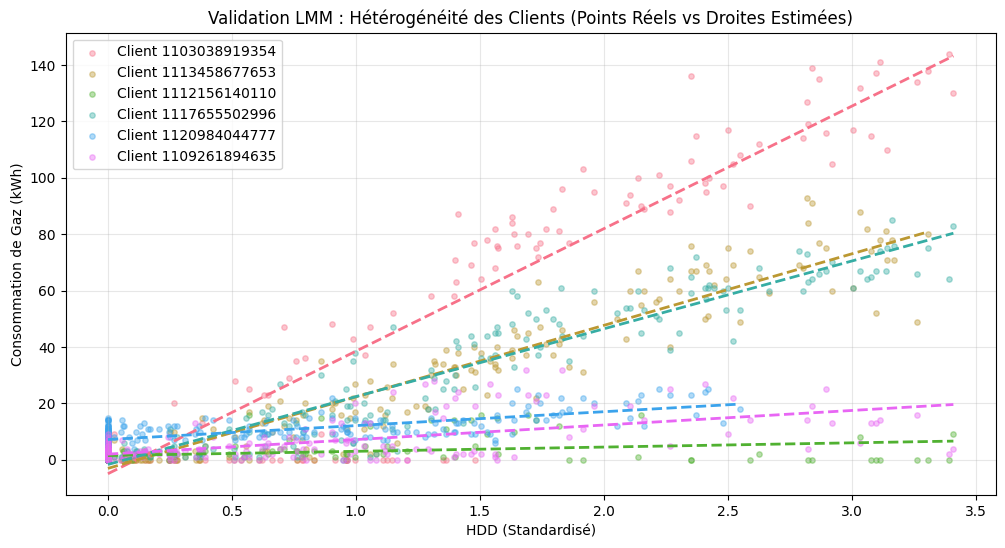

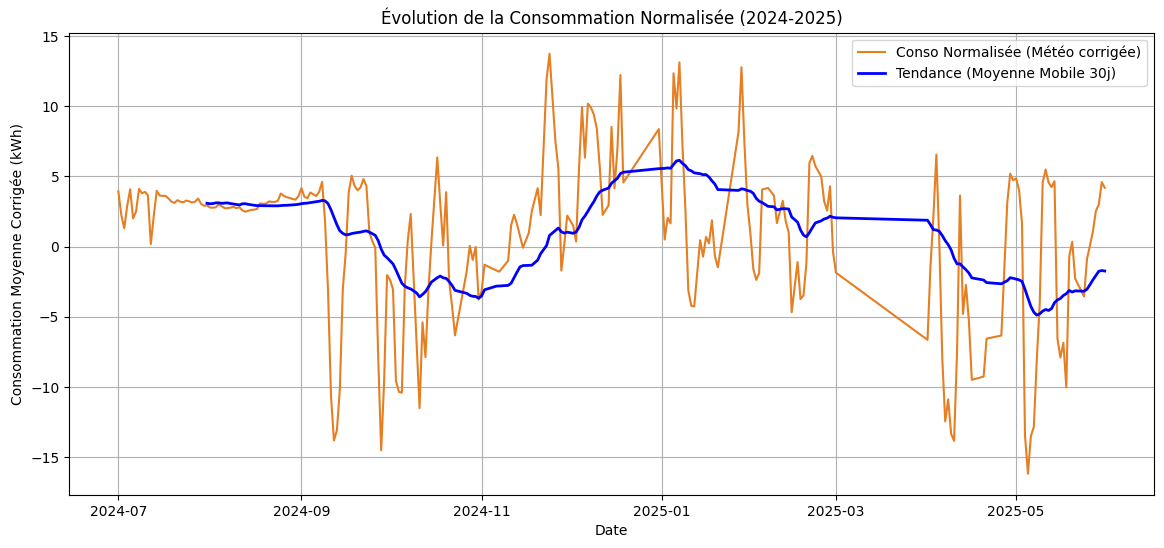

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# On s'assure d'avoir les données du modèle précédent (df_results)
# Si df_results n'existe pas, relancez le bloc de code LMM précédent

# --- GRAPHIQUE 1 : SCATTER PLOT AVEC RÉGRESSIONS INDIVIDUELLES (Comme Page 10) ---
# Objectif : Montrer que chaque client réagit différemment au froid (Pentes aléatoires)

# 1. Sélection de 5 clients aléatoires pour ne pas surcharger le graphique
sample_pces = np.random.choice(df_results['pce'].unique(), 6, replace=False)
subset_plot = df_results[df_results['pce'].isin(sample_pces)].copy()

plt.figure(figsize=(12, 6))

# Palette de couleurs pour distinguer les clients
colors = sns.color_palette("husl", len(sample_pces))

for i, pce in enumerate(sample_pces):
    pce_data = subset_plot[subset_plot['pce'] == pce]
    color = colors[i]
    
    # A. Points réels (Nuage de points)
    plt.scatter(pce_data['hdd_scaled'], pce_data['valeur_energie_conso'], 
                alpha=0.4, s=15, color=color, label=f"Client {pce}")
    
    # B. Droite du Modèle LMM (Pente spécifique à ce client)
    # y = (Intercept_Fixe + Intercept_Random) + (Pente_Fixe + Pente_Random) * X
    # Note : On récupère l'intercept du modèle global
    intercept_fixed = result_lmm.params['Intercept']
    intercept_total = intercept_fixed + pce_data['intercept_random'].iloc[0]
    slope_total = pce_data['total_hdd_slope'].iloc[0]
    
    # Création de la ligne de régression
    x_vals = np.array([pce_data['hdd_scaled'].min(), pce_data['hdd_scaled'].max()])
    y_vals = intercept_total + slope_total * x_vals
    
    plt.plot(x_vals, y_vals, color=color, linewidth=2, linestyle='--')

plt.title("Validation LMM : Hétérogénéité des Clients (Points Réels vs Droites Estimées)")
plt.xlabel("HDD (Standardisé)")
plt.ylabel("Consommation de Gaz (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- GRAPHIQUE 2 : ÉVOLUTION TEMPORELLE NORMALISÉE (Comme Page 17) ---
# Objectif : Voir la courbe de consommation "nettoyée" de la météo

plt.figure(figsize=(14, 6))

# On agrège par jour pour alléger le graphique
daily_trend = df_results.groupby('date_parsed')['conso_norm'].mean()

# Tracé de la courbe
plt.plot(daily_trend.index, daily_trend.values, color='#e67e22', linewidth=1.5, label='Conso Normalisée (Météo corrigée)')

# Ajout d'une moyenne mobile pour voir la tendance de fond (Trend)
plt.plot(daily_trend.rolling(window=30).mean().index, 
         daily_trend.rolling(window=30).mean().values, 
         color='blue', linewidth=2, linestyle='-', label='Tendance (Moyenne Mobile 30j)')

plt.title("Évolution de la Consommation Normalisée (2024-2025)")
plt.ylabel("Consommation Moyenne Corrigée (kWh)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()